/tmp/ipykernel_1934/2146238839.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Data saved to 'population_data.csv'
Plots saved as 'age_distribution.png' and 'gender_distribution.png'


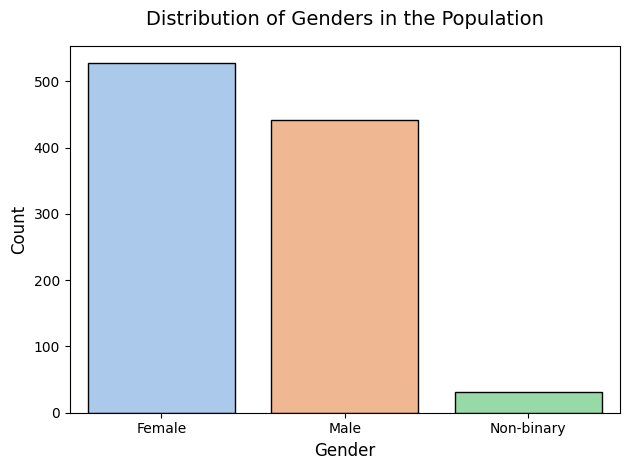

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup and Data Generation
# Set a random seed for reproducible results
np.random.seed(42)
n_samples = 1000

# Continuous variable: Age (simulated using a beta distribution to look realistic)
ages = np.random.beta(a=2, b=3, size=n_samples) * 85 + 5
ages = np.round(ages).astype(int)

# Categorical variable: Gender (with specified population weights)
genders = np.random.choice(['Female', 'Male', 'Non-binary'], size=n_samples, p=[0.51, 0.46, 0.03])

# Create a DataFrame
df = pd.DataFrame({
    'Age': ages,
    'Gender': genders
})

# Save dataset to a CSV file
df.to_csv('population_data.csv', index=False)


# 2. Visualize Continuous Variable: Age (Histogram)
plt.clf()  # Clear any previous figures
sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='black'
)

# Customizing the plot labels and titles
plt.title('Distribution of Ages in the Population', fontsize=14, pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()

# Save the histogram
plt.savefig('age_distribution.png', dpi=300)


# 3. Visualize Categorical Variable: Gender (Bar Chart)
plt.clf()  # Clear the figure for the new plot

# Sort the categories by frequency in descending order
gender_counts = df['Gender'].value_counts().sort_values(ascending=False)

# Create the bar chart
sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette='pastel',
    edgecolor='black'
)

# Customizing the plot labels and titles
plt.title('Distribution of Genders in the Population', fontsize=14, pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()

# Save the bar chart
plt.savefig('gender_distribution.png', dpi=300)

print("Data saved to 'population_data.csv'")
print("Plots saved as 'age_distribution.png' and 'gender_distribution.png'")

/tmp/ipykernel_1934/3803875562.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


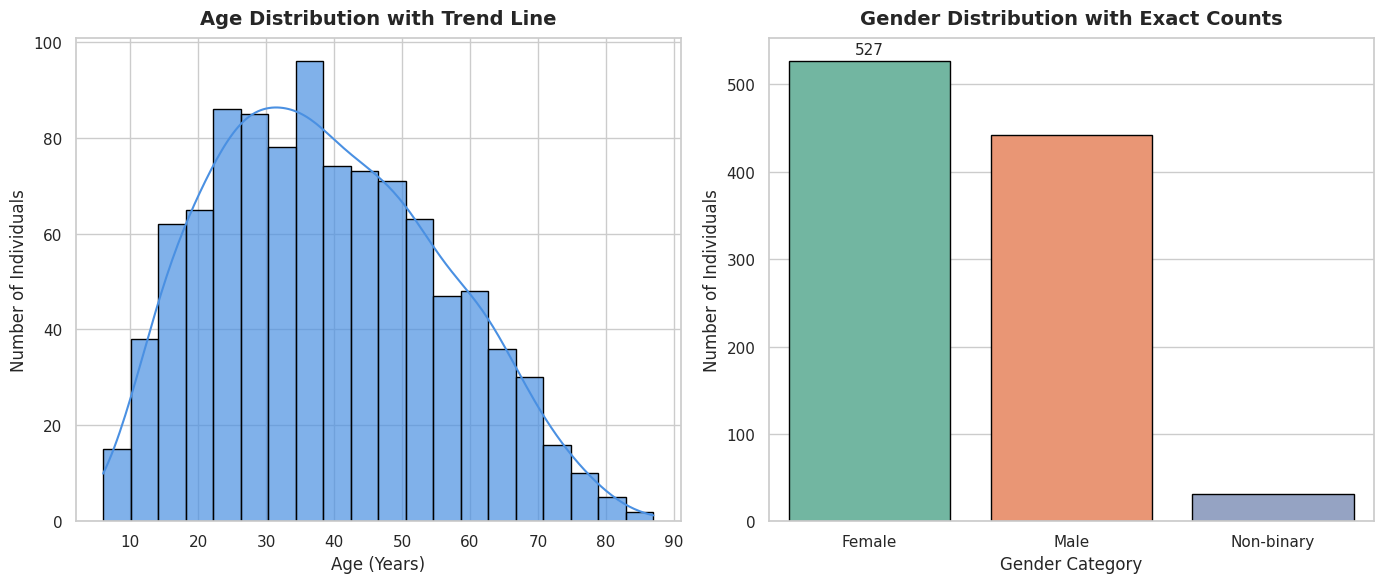

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (Assuming df is already loaded from the previous step)
# Set style for a clean look
sns.set_theme(style="whitegrid")

# Create a single figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Subplot: Advanced Histogram (Age) ---
sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,
    color='#4a90e2',
    edgecolor='black',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Age Distribution with Trend Line', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Age (Years)', fontsize=12)
axes[0].set_ylabel('Number of Individuals', fontsize=12)

# --- Right Subplot: Bar Chart with Value Annotations (Gender) ---
gender_counts = df['Gender'].value_counts().sort_values(ascending=False)

# Capture the bar container to add text labels
bars = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette='Set2',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Gender Distribution with Exact Counts', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Gender Category', fontsize=12)
axes[1].set_ylabel('Number of Individuals', fontsize=12)

# Automatically add the value labels on top of each bar
axes[1].bar_label(axes[1].containers[0], fmt='%d', fontsize=11, padding=3)

# Adjust layout to prevent text clipping
plt.tight_layout()
plt.savefig('combined_population_plots.png', dpi=300)